# Brain Tumor Detection Benchmark — Results Analysis and Model Selection

This notebook is a clean analysis companion for the repository.

It does **not** retrain models.  
It loads or defines benchmark results, visualizes the classical vs hybrid performance, and explains how the final ensemble candidates were selected.

Main selection priority:

> In medical screening, false negatives are the most critical error because a tumor image classified as non-tumor may delay diagnosis. Therefore, this analysis prioritizes models with the lowest false negative count.


## 1. Imports

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

ROOT = Path("..")
RESULTS_DIR = ROOT / "results"

print("Notebook ready.")
print("Expected project root:", ROOT.resolve())

Notebook ready.
Expected project root: C:\Users\Hossein\Desktop\Hossein\Projects\Cancer-Detection-Benchmarking\Benchmarking-Models-for-Brain-Tumor-Detection-Using-MRI-Images


## 2. Top selected models

The table below represents the final selected model per backbone family.  
Each backbone was compared against its classical and hybrid variants, and the model with the lowest false negative count was selected.


In [2]:
top_models = pd.DataFrame([
    {
        "model_name": "ResNet50V2",
        "model_type": "hybrid",
        "n_qubits": 12,
        "q_depth": 2,
        "fn": 1,
        "fp": 6,
        "tn": 1044,
        "tp": 928,
        "training_time_sec": 11596.3,
        "accuracy": 0.996463,
        "precision": 0.993576,
        "recall_sensitivity": 0.998924,
        "specificity": 0.994286,
        "f1_score": 0.996243,
        "roc_auc": 0.996338,
    },
    {
        "model_name": "VGG16",
        "model_type": "classical CNN",
        "n_qubits": np.nan,
        "q_depth": np.nan,
        "fn": 2,
        "fp": 4,
        "tn": 1046,
        "tp": 927,
        "training_time_sec": 33731.1,
        "accuracy": 0.996968,
        "precision": 0.995704,
        "recall_sensitivity": 0.997847,
        "specificity": 0.996190,
        "f1_score": 0.996774,
        "roc_auc": 0.999958,
    },
    {
        "model_name": "DenseNet201",
        "model_type": "classical CNN",
        "n_qubits": np.nan,
        "q_depth": np.nan,
        "fn": 3,
        "fp": 1,
        "tn": 1049,
        "tp": 926,
        "training_time_sec": 21920.5,
        "accuracy": 0.997979,
        "precision": 0.998921,
        "recall_sensitivity": 0.996771,
        "specificity": 0.999048,
        "f1_score": 0.997845,
        "roc_auc": 0.999875,
    },
    {
        "model_name": "EfficientNetB0",
        "model_type": "hybrid",
        "n_qubits": 4,
        "q_depth": 2,
        "fn": 3,
        "fp": 4,
        "tn": 1046,
        "tp": 926,
        "training_time_sec": 14118.9,
        "accuracy": 0.996463,
        "precision": 0.995699,
        "recall_sensitivity": 0.996771,
        "specificity": 0.996190,
        "f1_score": 0.996235,
        "roc_auc": 0.999721,
    },
    {
        "model_name": "MobileNetV2",
        "model_type": "hybrid",
        "n_qubits": 12,
        "q_depth": 2,
        "fn": 3,
        "fp": 14,
        "tn": 1036,
        "tp": 926,
        "training_time_sec": 10818.8,
        "accuracy": 0.991410,
        "precision": 0.985106,
        "recall_sensitivity": 0.996771,
        "specificity": 0.986667,
        "f1_score": 0.990904,
        "roc_auc": 0.999552,
    },
    {
        "model_name": "VGG19",
        "model_type": "classical CNN",
        "n_qubits": np.nan,
        "q_depth": np.nan,
        "fn": 4,
        "fp": 6,
        "tn": 1044,
        "tp": 925,
        "training_time_sec": 41627.5,
        "accuracy": 0.994947,
        "precision": 0.993555,
        "recall_sensitivity": 0.995694,
        "specificity": 0.994286,
        "f1_score": 0.994624,
        "roc_auc": 0.999836,
    },
    {
        "model_name": "Xception",
        "model_type": "hybrid",
        "n_qubits": 8,
        "q_depth": 2,
        "fn": 4,
        "fp": 8,
        "tn": 1042,
        "tp": 925,
        "training_time_sec": 36796.1,
        "accuracy": 0.993936,
        "precision": 0.991426,
        "recall_sensitivity": 0.995694,
        "specificity": 0.992381,
        "f1_score": 0.993555,
        "roc_auc": 0.999489,
    },
    {
        "model_name": "InceptionV3",
        "model_type": "hybrid",
        "n_qubits": 4,
        "q_depth": 2,
        "fn": 5,
        "fp": 9,
        "tn": 1041,
        "tp": 924,
        "training_time_sec": 6186.18,
        "accuracy": 0.992926,
        "precision": 0.990354,
        "recall_sensitivity": 0.994618,
        "specificity": 0.991429,
        "f1_score": 0.992481,
        "roc_auc": 0.992033,
    },
    {
        "model_name": "DenseNet121",
        "model_type": "hybrid",
        "n_qubits": 6,
        "q_depth": 2,
        "fn": 6,
        "fp": 5,
        "tn": 1045,
        "tp": 923,
        "training_time_sec": 8926.21,
        "accuracy": 0.994442,
        "precision": 0.994612,
        "recall_sensitivity": 0.993541,
        "specificity": 0.995238,
        "f1_score": 0.994076,
        "roc_auc": 0.997766,
    },
])

top_models = top_models.sort_values(["fn", "fp", "recall_sensitivity"], ascending=[True, True, False]).reset_index(drop=True)
top_models

,model_name,model_type,n_qubits,q_depth,fn,fp,tn,tp,training_time_sec,accuracy,precision,recall_sensitivity,specificity,f1_score,roc_auc
0,ResNet50V2,hybrid,12.0,2.0,1,6,1044,928,11596.30,0.996463,0.993576,0.998924,0.994286,0.996243,0.996338
1,VGG16,classical CNN,NaN,NaN,2,4,1046,927,33731.10,0.996968,0.995704,0.997847,0.996190,0.996774,0.999958
2,DenseNet201,classical CNN,NaN,NaN,3,1,1049,926,21920.50,0.997979,0.998921,0.996771,0.999048,0.997845,0.999875
3,EfficientNetB0,hybrid,4.0,2.0,3,4,1046,926,14118.90,0.996463,0.995699,0.996771,0.996190,0.996235,0.999721
4,MobileNetV2,hybrid,12.0,2.0,3,14,1036,926,10818.80,0.991410,0.985106,0.996771,0.986667,0.990904,0.999552
5,VGG19,classical CNN,NaN,NaN,4,6,1044,925,41627.50,0.994947,0.993555,0.995694,0.994286,0.994624,0.999836
6,Xception,hybrid,8.0,2.0,4,8,1042,925,36796.10,0.993936,0.991426,0.995694,0.992381,0.993555,0.999489
7,InceptionV3,hybrid,4.0,2.0,5,9,1041,924,6186.18,0.992926,0.990354,0.994618,0.991429,0.992481,0.992033
8,DenseNet121,hybrid,6.0,2.0,6,5,1045,923,8926.21,0.994442,0.994612,0.993541,0.995238,0.994076,0.997766


## 3. Basic model-family summary

In [3]:
summary_by_type = (
    top_models
    .groupby("model_type")
    .agg(
        count=("model_name", "count"),
        mean_fn=("fn", "mean"),
        min_fn=("fn", "min"),
        mean_recall=("recall_sensitivity", "mean"),
        mean_specificity=("specificity", "mean"),
        mean_auc=("roc_auc", "mean"),
        mean_training_time_sec=("training_time_sec", "mean"),
    )
    .reset_index()
)

summary_by_type

,model_type,count,mean_fn,min_fn,mean_recall,mean_specificity,mean_auc,mean_training_time_sec
0,classical CNN,3,3.000000,2,0.996771,0.996508,0.999890,32426.366667
1,hybrid,6,3.666667,1,0.996053,0.992698,0.997483,14740.415000


## 4. False negatives by selected model

Lower is better.  
This is the most important plot for the intended medical-screening use case.


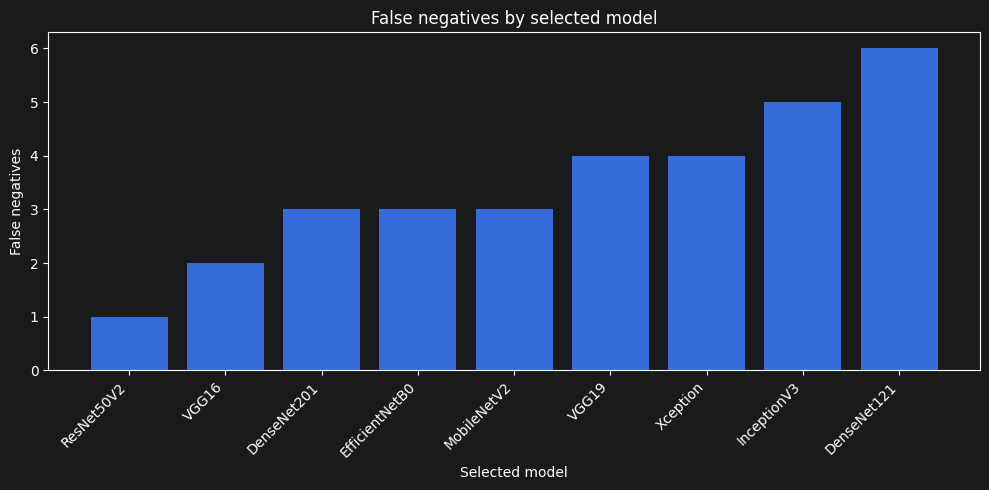

In [4]:
plot_df = top_models.sort_values("fn")

plt.figure(figsize=(10, 5))
plt.bar(plot_df["model_name"], plot_df["fn"])
plt.ylabel("False negatives")
plt.xlabel("Selected model")
plt.title("False negatives by selected model")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 5. False positives by selected model

False positives are less dangerous than false negatives in this screening-oriented setup, but they still matter because they increase unnecessary follow-up load.


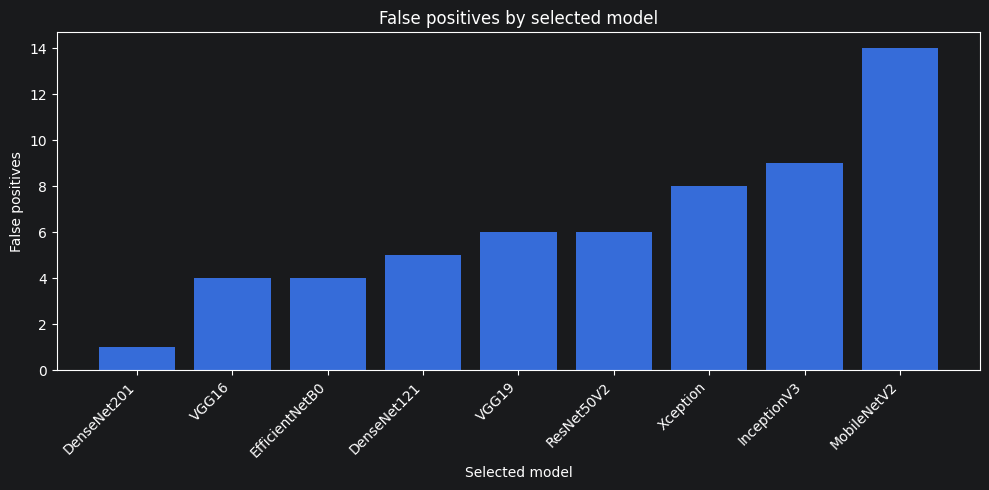

In [5]:
plot_df = top_models.sort_values("fp")

plt.figure(figsize=(10, 5))
plt.bar(plot_df["model_name"], plot_df["fp"])
plt.ylabel("False positives")
plt.xlabel("Selected model")
plt.title("False positives by selected model")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 6. Sensitivity vs specificity

Sensitivity corresponds to recall for the tumor class.  
Specificity measures how well the model identifies no-tumor cases.


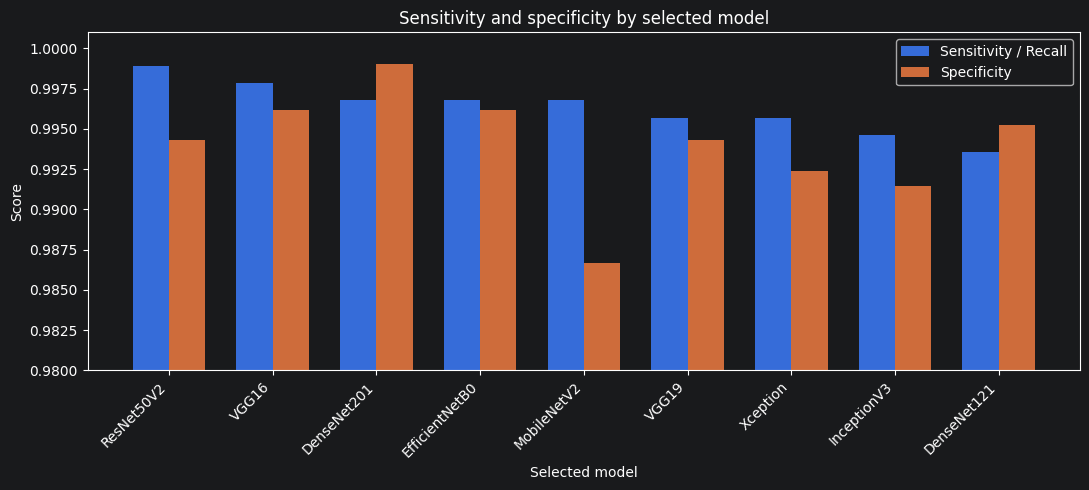

In [6]:
plot_df = top_models.copy()

x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(11, 5))
plt.bar(x - width/2, plot_df["recall_sensitivity"], width, label="Sensitivity / Recall")
plt.bar(x + width/2, plot_df["specificity"], width, label="Specificity")
plt.ylabel("Score")
plt.xlabel("Selected model")
plt.title("Sensitivity and specificity by selected model")
plt.xticks(x, plot_df["model_name"], rotation=45, ha="right")
plt.ylim(0.98, 1.001)
plt.legend()
plt.tight_layout()
plt.show()

## 7. Training time comparison

This is useful for discussing practical cost.  
Hybrid quantum-classical models may be competitive in predictive metrics, but training time and computational complexity must also be considered.


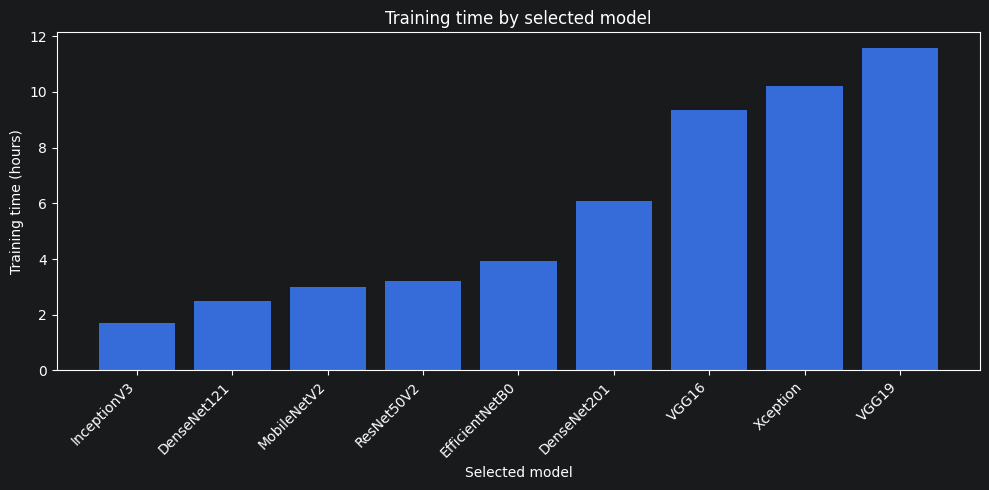

In [7]:
plot_df = top_models.sort_values("training_time_sec")

plt.figure(figsize=(10, 5))
plt.bar(plot_df["model_name"], plot_df["training_time_sec"] / 3600)
plt.ylabel("Training time (hours)")
plt.xlabel("Selected model")
plt.title("Training time by selected model")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 8. Classical vs hybrid count among selected models

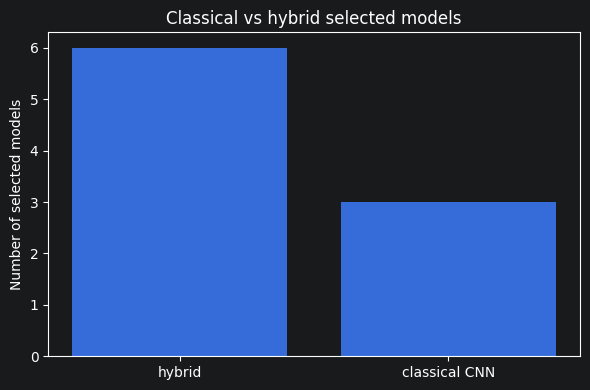

model_type
hybrid           6
classical CNN    3
Name: count, dtype: int64

In [8]:
counts = top_models["model_type"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(counts.index, counts.values)
plt.ylabel("Number of selected models")
plt.title("Classical vs hybrid selected models")
plt.tight_layout()
plt.show()

counts

## 9. Ensemble decision rule

The proposed software uses a sensitivity-first ensemble rule:

> If at least one selected model predicts tumor, the final output is tumor.  
> Only if all selected models predict no tumor, the final output is no tumor.

This rule is intentionally conservative. It is designed to reduce false negatives, accepting the possibility of more false positives.


In [9]:
def sensitivity_first_ensemble(binary_predictions):
    """
    binary_predictions: iterable of 0/1 predictions from selected models
    0 = no tumor
    1 = tumor

    Returns:
        final_prediction: 0 or 1
        tumor_votes: number of models voting tumor
        total_models: total number of models
    """
    binary_predictions = np.asarray(binary_predictions).astype(int)
    tumor_votes = int(binary_predictions.sum())
    final_prediction = int(tumor_votes >= 1)
    return final_prediction, tumor_votes, len(binary_predictions)


example_predictions = [0, 0, 0, 1, 0, 0, 0, 0, 0]
final_prediction, tumor_votes, total_models = sensitivity_first_ensemble(example_predictions)

print("Example predictions:", example_predictions)
print("Tumor votes:", tumor_votes, "/", total_models)
print("Final prediction:", "tumor" if final_prediction == 1 else "no tumor")

Example predictions: [0, 0, 0, 1, 0, 0, 0, 0, 0]
Tumor votes: 1 / 9
Final prediction: tumor


## 10. Why pure QNN was not selected for the software

Pure/native QNNs are not used in the current software prototype because the main difficulty is feature extraction.

A raw MRI image contains tens of thousands of pixel values. Current QNN pipelines require aggressive dimensionality reduction before quantum encoding. Simple PCA is linear and much weaker than CNN feature extraction. Autoencoders are stronger than PCA, but they are still not label-discriminative in the same way supervised CNN feature extractors are.

Therefore, for this practical decision-support prototype, the selected models are classical CNNs and hybrid CNN-QNN models, where the CNN backbone provides a strong learned feature representation.


## 11. Final selected ensemble candidates

In [10]:
final_columns = [
    "model_name",
    "model_type",
    "n_qubits",
    "q_depth",
    "fn",
    "fp",
    "tn",
    "tp",
    "recall_sensitivity",
    "specificity",
    "accuracy",
    "precision",
    "f1_score",
    "roc_auc",
    "training_time_sec",
]

final_selection = top_models[final_columns].copy()
final_selection

,model_name,model_type,n_qubits,q_depth,fn,fp,tn,tp,recall_sensitivity,specificity,accuracy,precision,f1_score,roc_auc,training_time_sec
0,ResNet50V2,hybrid,12.0,2.0,1,6,1044,928,0.998924,0.994286,0.996463,0.993576,0.996243,0.996338,11596.30
1,VGG16,classical CNN,NaN,NaN,2,4,1046,927,0.997847,0.996190,0.996968,0.995704,0.996774,0.999958,33731.10
2,DenseNet201,classical CNN,NaN,NaN,3,1,1049,926,0.996771,0.999048,0.997979,0.998921,0.997845,0.999875,21920.50
3,EfficientNetB0,hybrid,4.0,2.0,3,4,1046,926,0.996771,0.996190,0.996463,0.995699,0.996235,0.999721,14118.90
4,MobileNetV2,hybrid,12.0,2.0,3,14,1036,926,0.996771,0.986667,0.991410,0.985106,0.990904,0.999552,10818.80
5,VGG19,classical CNN,NaN,NaN,4,6,1044,925,0.995694,0.994286,0.994947,0.993555,0.994624,0.999836,41627.50
6,Xception,hybrid,8.0,2.0,4,8,1042,925,0.995694,0.992381,0.993936,0.991426,0.993555,0.999489,36796.10
7,InceptionV3,hybrid,4.0,2.0,5,9,1041,924,0.994618,0.991429,0.992926,0.990354,0.992481,0.992033,6186.18
8,DenseNet121,hybrid,6.0,2.0,6,5,1045,923,0.993541,0.995238,0.994442,0.994612,0.994076,0.997766,8926.21


## 12. Save final selected model table

This CSV can be used later by the software prototype to document which models are included in the ensemble.


In [11]:
output_dir = ROOT / "results" / "analysis"
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / "selected_ensemble_models.csv"
final_selection.to_csv(output_path, index=False)

print("Saved:", output_path.resolve())

Saved: C:\Users\Hossein\Desktop\Hossein\Projects\Cancer-Detection-Benchmarking\Benchmarking-Models-for-Brain-Tumor-Detection-Using-MRI-Images\results\analysis\selected_ensemble_models.csv


## 13. Conclusion

The benchmark shows that both classical CNNs and hybrid CNN-QNN models can achieve strong performance on the MRI tumor detection task.

The final ensemble is selected with a medical-screening priority: minimizing false negatives.  
The software prototype should therefore use these selected models as a conservative decision-support system, not as a standalone diagnostic tool.

Future software extensions:
- Grad-CAM or Grad-CAM++ heatmaps
- suspicious-region bounding boxes
- batch image upload
- automatic image conversion
- PDF/CSV report export
- external clinical validation
